
# 06 — Change Detection: Ongoing Land Monitoring

This notebook builds feature #13 from the product's build matrix: periodically re-scanning land the
platform has verified, and automatically flagging areas that have visibly changed — new construction,
encroachment, or unauthorized development. This is where the CV and GeoPandas curricula fully merge: the
output of this notebook is a **vector polygon** (an alert area), computed *from* a raster comparison, that
you can then check against your existing parcel boundaries using tools from the GeoPandas curriculum.

## The approach: structural similarity, not pixel differencing

You could compare two images pixel-by-pixel, but raw pixel differences are extremely sensitive to
irrelevant changes — lighting, seasonal vegetation color shifts, minor sensor noise between two different
satellite passes. **Structural Similarity (SSIM)**, from scikit-image, compares local patterns
(luminance, contrast, structure) in a way that's much more robust to those irrelevant differences, and is
the standard technique for this kind of "did something meaningfully change here" comparison.


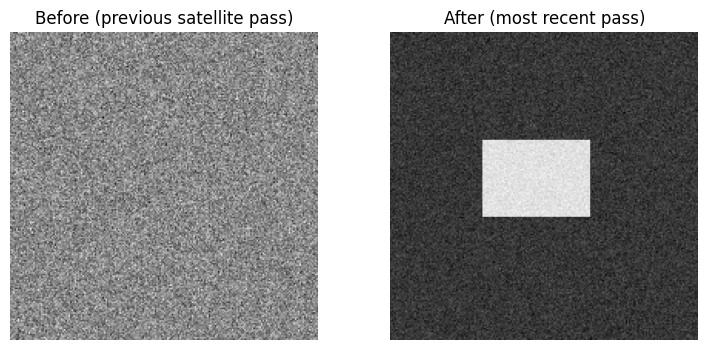

In [1]:

import numpy as np
import matplotlib.pyplot as plt
from skimage.metrics import structural_similarity as ssim
import cv2

# Simulate two satellite passes of the same area: "before" (empty/vegetated land) and
# "after" (a new structure has appeared) — mimicking unauthorized construction on land
# the platform has already verified as vacant
np.random.seed(8)
size = 200

def make_land_image(add_structure=False):
    base = np.random.normal(100, 8, (size, size)).astype(np.float32)  # relatively uniform vegetated land
    if add_structure:
        # a new rectangular structure — brighter, more uniform than surrounding vegetation,
        # like a real building/roof would appear in imagery
        base[70:120, 60:130] = np.random.normal(200, 5, (50, 70))
    return np.clip(base, 0, 255).astype(np.uint8)

before = make_land_image(add_structure=False)
after = make_land_image(add_structure=True)

fig, axes = plt.subplots(1, 2, figsize=(9, 4))
axes[0].imshow(before, cmap="gray"); axes[0].set_title("Before (previous satellite pass)"); axes[0].axis("off")
axes[1].imshow(after, cmap="gray"); axes[1].set_title("After (most recent pass)"); axes[1].axis("off")
plt.show()



## Computing the structural difference map


Overall similarity score: 0.3110 (1.0 = identical, lower = more different)


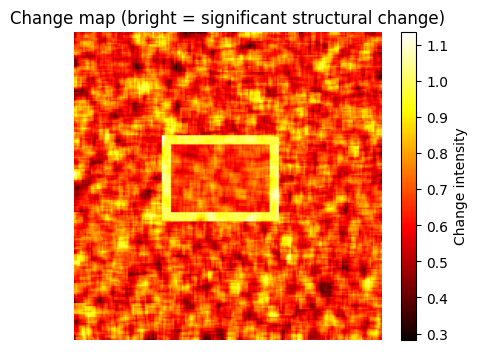

In [2]:

similarity_score, diff_map = ssim(before, after, full=True)

print(f"Overall similarity score: {similarity_score:.4f} (1.0 = identical, lower = more different)")

# diff_map has high values where the images are SIMILAR — invert it so high values mean CHANGE,
# which is more intuitive to threshold and visualize
change_map = 1 - diff_map

plt.figure(figsize=(5, 4))
plt.imshow(change_map, cmap="hot")
plt.colorbar(label="Change intensity")
plt.title("Change map (bright = significant structural change)")
plt.axis("off")
plt.show()



## Thresholding into a binary change mask

The change map is continuous (a degree of difference everywhere, including sensor noise). Thresholding
turns it into a clean binary decision: "changed" or "not changed," using OpenCV the same way notebook 01
used it for edge/contour work.


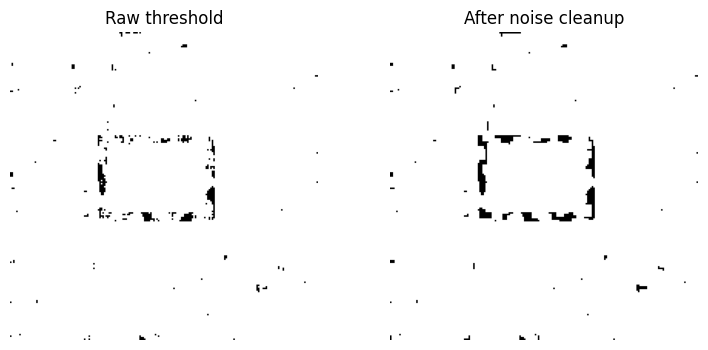

In [3]:

change_map_uint8 = (change_map * 255).astype(np.uint8)
_, change_mask = cv2.threshold(change_map_uint8, thresh=100, maxval=255, type=cv2.THRESH_BINARY)

# Clean up small, noisy specks with morphological opening — removes tiny isolated "changed" pixels
# that are almost certainly noise, not a real structure
kernel = np.ones((5, 5), np.uint8)
change_mask_clean = cv2.morphologyEx(change_mask, cv2.MORPH_OPEN, kernel)

fig, axes = plt.subplots(1, 2, figsize=(9, 4))
axes[0].imshow(change_mask, cmap="gray"); axes[0].set_title("Raw threshold"); axes[0].axis("off")
axes[1].imshow(change_mask_clean, cmap="gray"); axes[1].set_title("After noise cleanup"); axes[1].axis("off")
plt.show()



## Vectorizing the change mask — turning pixels into a real polygon

This is the key step that reconnects to the GeoPandas curriculum: `rasterio.features.shapes()` converts
regions of a raster mask into vector polygons, **using the raster's real geotransform**, so the resulting
polygon has genuine real-world coordinates — not just pixel coordinates.


In [4]:

import rasterio
from rasterio.transform import from_origin
from rasterio.features import shapes
from shapely.geometry import shape
import geopandas as gpd

# Give this synthetic raster a real geotransform, the same way notebook 05 did
transform = from_origin(west=9.24, north=4.16, xsize=0.0002, ysize=0.0002)

# shapes() expects the mask as a specific dtype, and yields (geometry, value) pairs for
# each connected region — we only care about regions where the mask value is 255 (changed)
change_polygons = []
for geom, value in shapes(change_mask_clean, transform=transform):
    if value == 255:
        change_polygons.append(shape(geom))

alerts = gpd.GeoDataFrame({"alert_type": ["unauthorized_change"] * len(change_polygons)},
                            geometry=change_polygons, crs="EPSG:4326")
print(f"Detected {len(alerts)} distinct change region(s), as real georeferenced polygons.")
alerts


Detected 1 distinct change region(s), as real georeferenced polygons.


,alert_type,geometry
0,unauthorized_change,"POLYGON ((9.24 4.16, 9.24 4.156, 9.2404 4.156,..."



## Closing the loop: checking alerts against your existing parcel database

This is exactly the kind of query the GeoPandas curriculum's `sjoin`/spatial-index tools were built for
— now applied to an alert generated from imagery, not from a manually submitted parcel.


In [5]:

from shapely.geometry import Polygon

# A parcel that (per your records) should be vacant land — the same coordinate area as the imagery above
monitored_parcel = gpd.GeoDataFrame(
    {"parcel_id": ["PARC-0042"], "owner_name": ["Mballa Family Trust"], "status": ["vacant, verified 2025"]},
    geometry=[Polygon([(9.240, 4.155), (9.250, 4.155), (9.250, 4.165), (9.240, 4.165)])],
    crs="EPSG:4326",
)

# The same spatial join pattern from the GeoPandas curriculum's notebook 02
flagged = gpd.sjoin(alerts, monitored_parcel, how="inner", predicate="intersects")

if len(flagged) > 0:
    print("ALERT: unauthorized change detected on a parcel recorded as vacant:")
    print(flagged[["alert_type", "parcel_id", "owner_name", "status"]])
else:
    print("No changes detected within any monitored parcel this pass.")


ALERT: unauthorized change detected on a parcel recorded as vacant:
            alert_type  parcel_id           owner_name                 status
0  unauthorized_change  PARC-0042  Mballa Family Trust  vacant, verified 2025



This is the complete real pipeline for feature #13: **raw imagery comparison → structural difference →
cleaned binary mask → real-world vector polygon → spatial join against your parcel database → an actual
actionable alert**, with no manual step in between.

## Exercises

### Exercise 1
Lower the `thresh` value in the thresholding cell (try `thresh=50`) and observe what happens to the
number and shape of detected change polygons. This is the same "threshold tuning trade-off" idea from
notebook 02's forensic flags — too sensitive and you get noisy false alerts, too strict and you miss real
changes.


In [6]:
# Your code here


#### Solution

In [7]:

_, sensitive_mask = cv2.threshold(change_map_uint8, thresh=50, maxval=255, type=cv2.THRESH_BINARY)
sensitive_mask_clean = cv2.morphologyEx(sensitive_mask, cv2.MORPH_OPEN, kernel)

sensitive_polygons = [shape(geom) for geom, value in shapes(sensitive_mask_clean, transform=transform) if value == 255]
print(f"With a lower (more sensitive) threshold: {len(sensitive_polygons)} region(s) detected")
print(f"Compare to {len(change_polygons)} region(s) with the original threshold — a lower threshold")
print("typically catches more area but is more prone to flagging noise as a real change.")


With a lower (more sensitive) threshold: 1 region(s) detected
Compare to 1 region(s) with the original threshold — a lower threshold
typically catches more area but is more prone to flagging noise as a real change.



### Exercise 2
Write a function `monitor_parcels(before_path, after_path, parcels_gdf, threshold=100)` that wraps this
entire pipeline — load two raster files, compute the change mask, vectorize it, and return only the
parcels from `parcels_gdf` that intersect a detected change. This is the function that would run on a
schedule (a cron job, per the product's implementation plan) against every actively monitored parcel.


In [8]:
# Your code here


#### Solution

In [9]:

def monitor_parcels(before_arr, after_arr, transform, parcels_gdf, threshold=100):
    _, diff_map = ssim(before_arr, after_arr, full=True)
    change_map = ((1 - diff_map) * 255).astype(np.uint8)
    _, mask = cv2.threshold(change_map, threshold, 255, cv2.THRESH_BINARY)
    mask_clean = cv2.morphologyEx(mask, cv2.MORPH_OPEN, np.ones((5, 5), np.uint8))

    polygons = [shape(geom) for geom, value in shapes(mask_clean, transform=transform) if value == 255]
    if not polygons:
        return parcels_gdf.iloc[0:0]  # empty GeoDataFrame, same schema

    alerts_gdf = gpd.GeoDataFrame(geometry=polygons, crs=parcels_gdf.crs)
    return gpd.sjoin(parcels_gdf, alerts_gdf, how="inner", predicate="intersects")

result = monitor_parcels(before, after, transform, monitored_parcel)
print(f"Parcels with detected changes: {len(result)}")
result[["parcel_id", "owner_name", "status"]] if len(result) else "None flagged"


Parcels with detected changes: 1


,parcel_id,owner_name,status
0,PARC-0042,Mballa Family Trust,"vacant, verified 2025"



## What's next

You now have every CV building block the product needs: document forensics (rule-based and trained),
satellite imagery handling, and change-detection monitoring. `07_capstone_cv_verification_module.ipynb`
combines all of it into one class, structured the way the real product's `services/cv/` module would be
— the CV-side sibling to the geospatial capstone from the earlier curriculum.
